In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
df0404 = pd.read_csv('../data/labeledAndAnomaly/no_plug/0404.csv')
df0712 = pd.read_csv('../data/labeledAndAnomaly/no_plug/0712.csv')
df1703 = pd.read_csv('../data/labeledAndAnomaly/no_plug/1703.csv')

df2108_1 = pd.read_csv('../data/labeledAndAnomaly/plug/2108-1.csv')
df2108_2 = pd.read_csv('../data/labeledAndAnomaly/plug/2108-2.csv')
df1112 = pd.read_csv('../data/labeledAndAnomaly/plug/1112.csv')
df1503 = pd.read_csv('../data/labeledAndAnomaly/plug/1503.csv')
df1003 = pd.read_csv('../data/labeledAndAnomaly/plug/1003.csv')

df1803 = pd.read_csv('../data/labeledAndAnomaly/partial_plug/1803.csv')
df1103 = pd.read_csv('../data/labeledAndAnomaly/partial_plug/1103.csv')
df2503 = pd.read_csv('../data/labeledAndAnomaly/partial_plug/2503.csv')

In [22]:
dfs = [df0404, df0712, df1703, df2108_1, df2108_2, df1112, df1503, df1003, df1803, df1103, df2503]
df_names = ['0404', '0712', '1703', '2108-1', '2108-2', '1112', '1503', '1003', '1803', '1103', '2503']

In [23]:
for df in dfs:
    df.drop(columns=['TS outlet pressure (Mean)', 'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)',
       'Differential pressure (Mean)', 'Pump to inlet DP', 'Total system DP',
       'Relative_DP', 'Pressure_Ratio',
       'rel_tot_dp_change', 'rel_ts_dp_change', 'rel_p_ts_dp_change', 'smooth_score'], inplace=True)

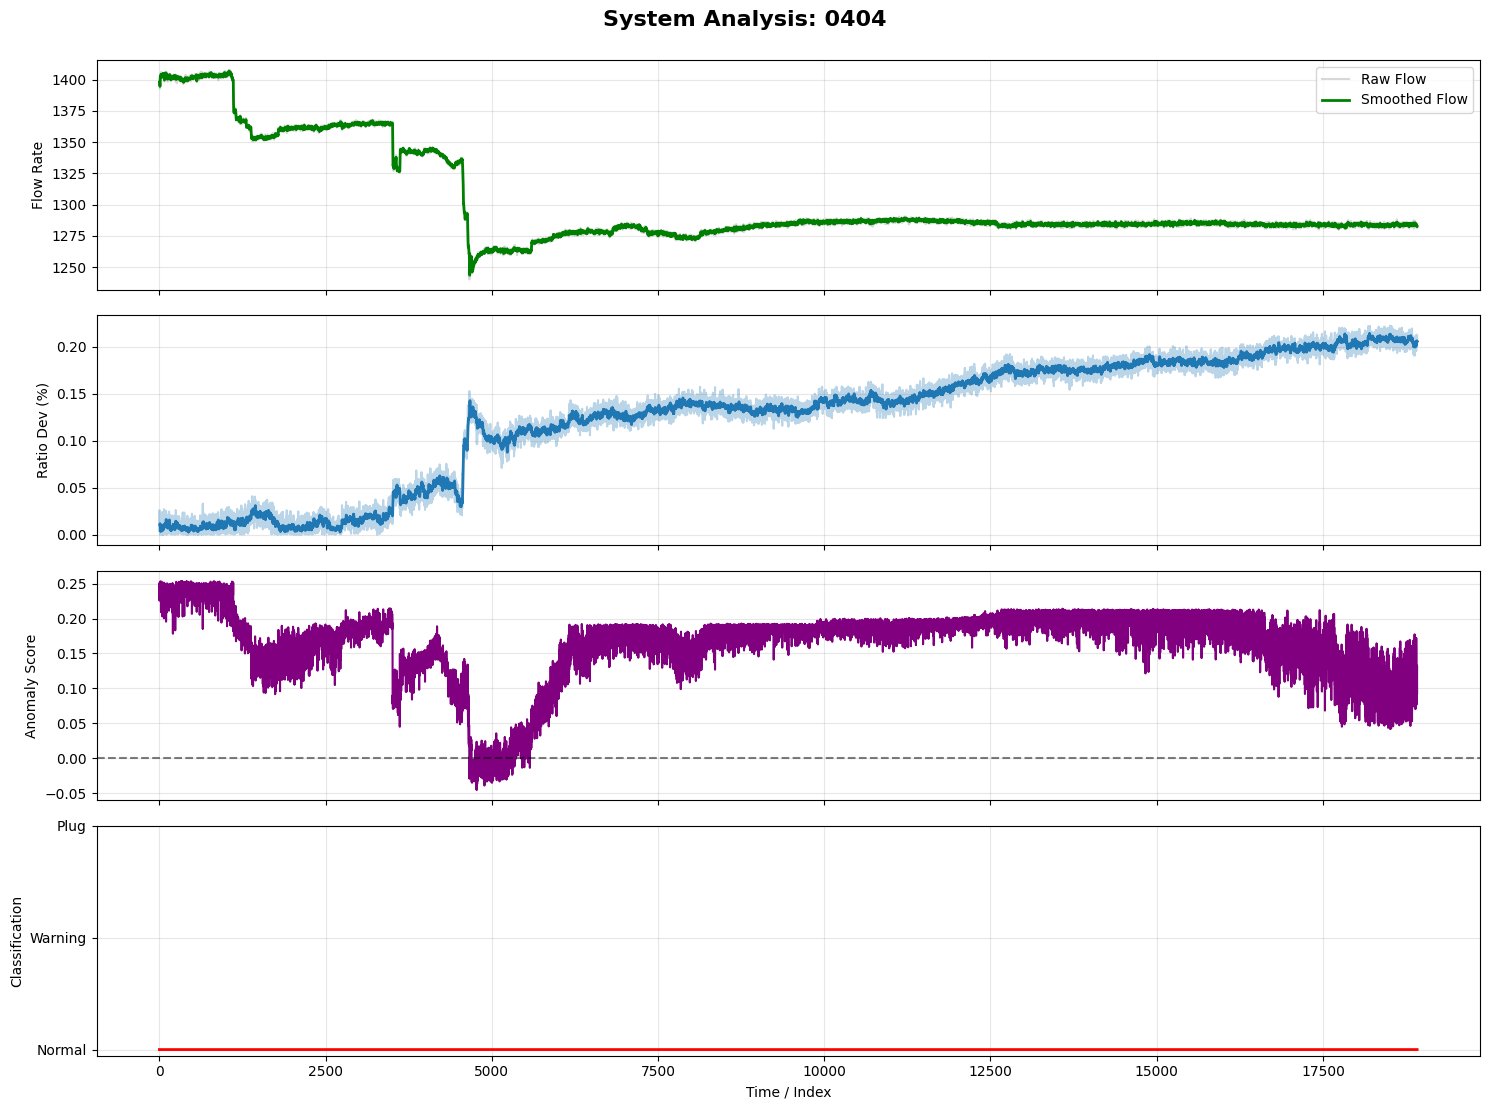

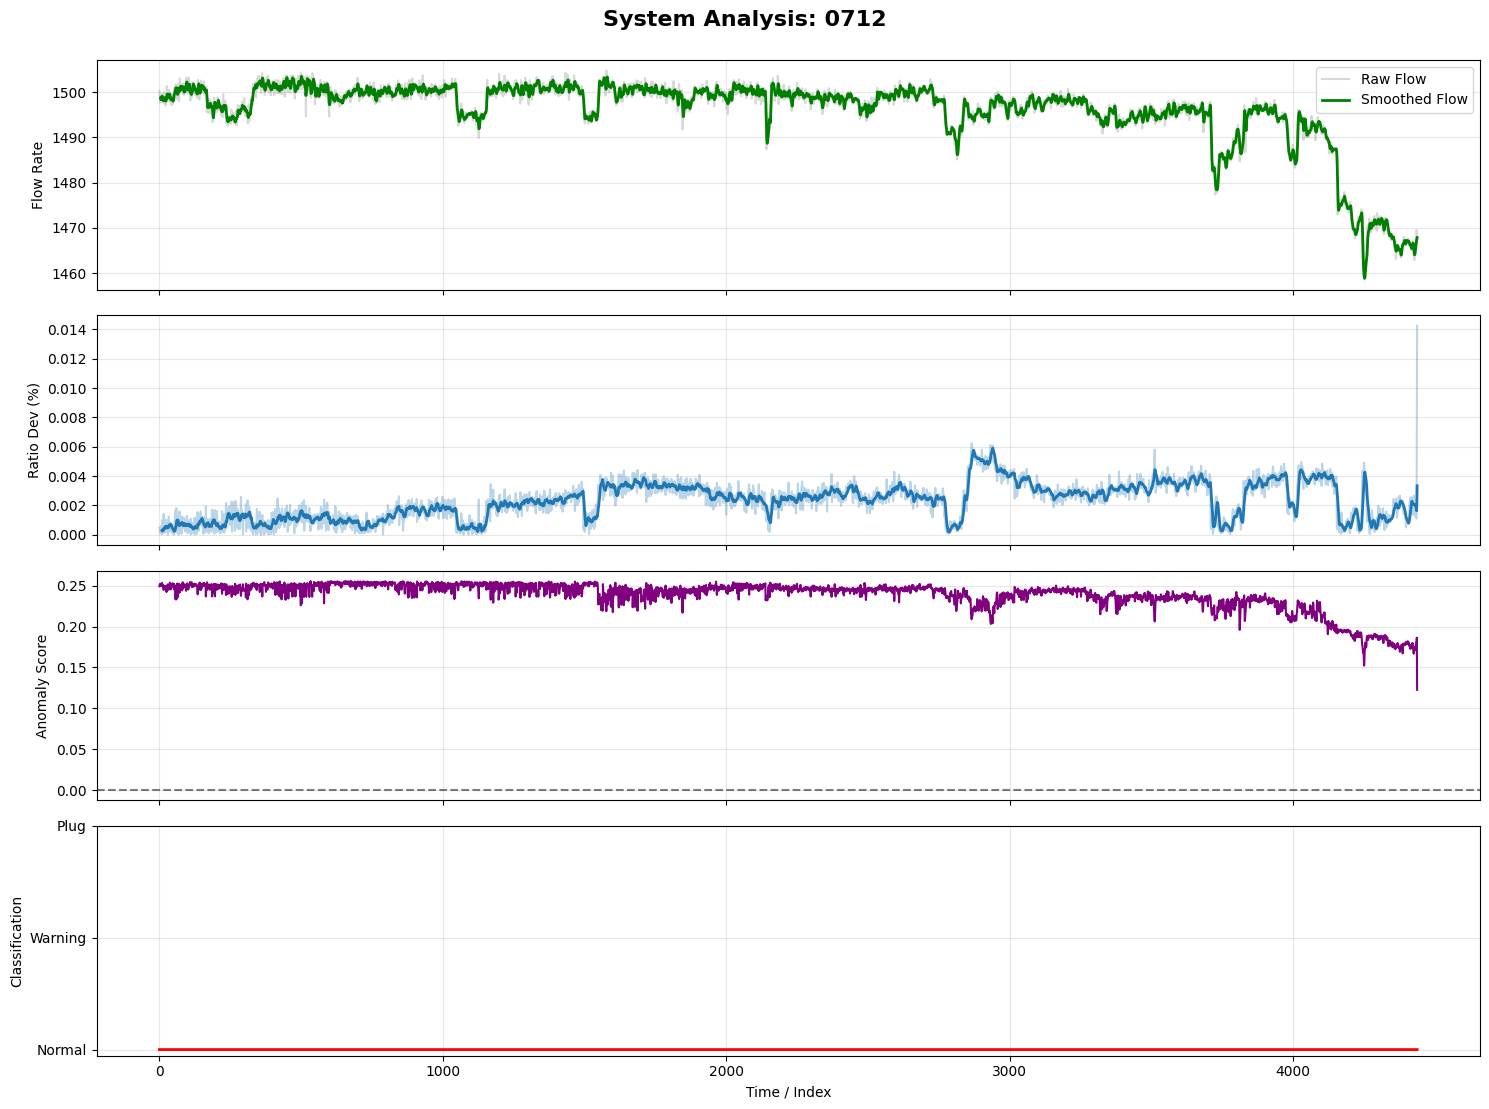

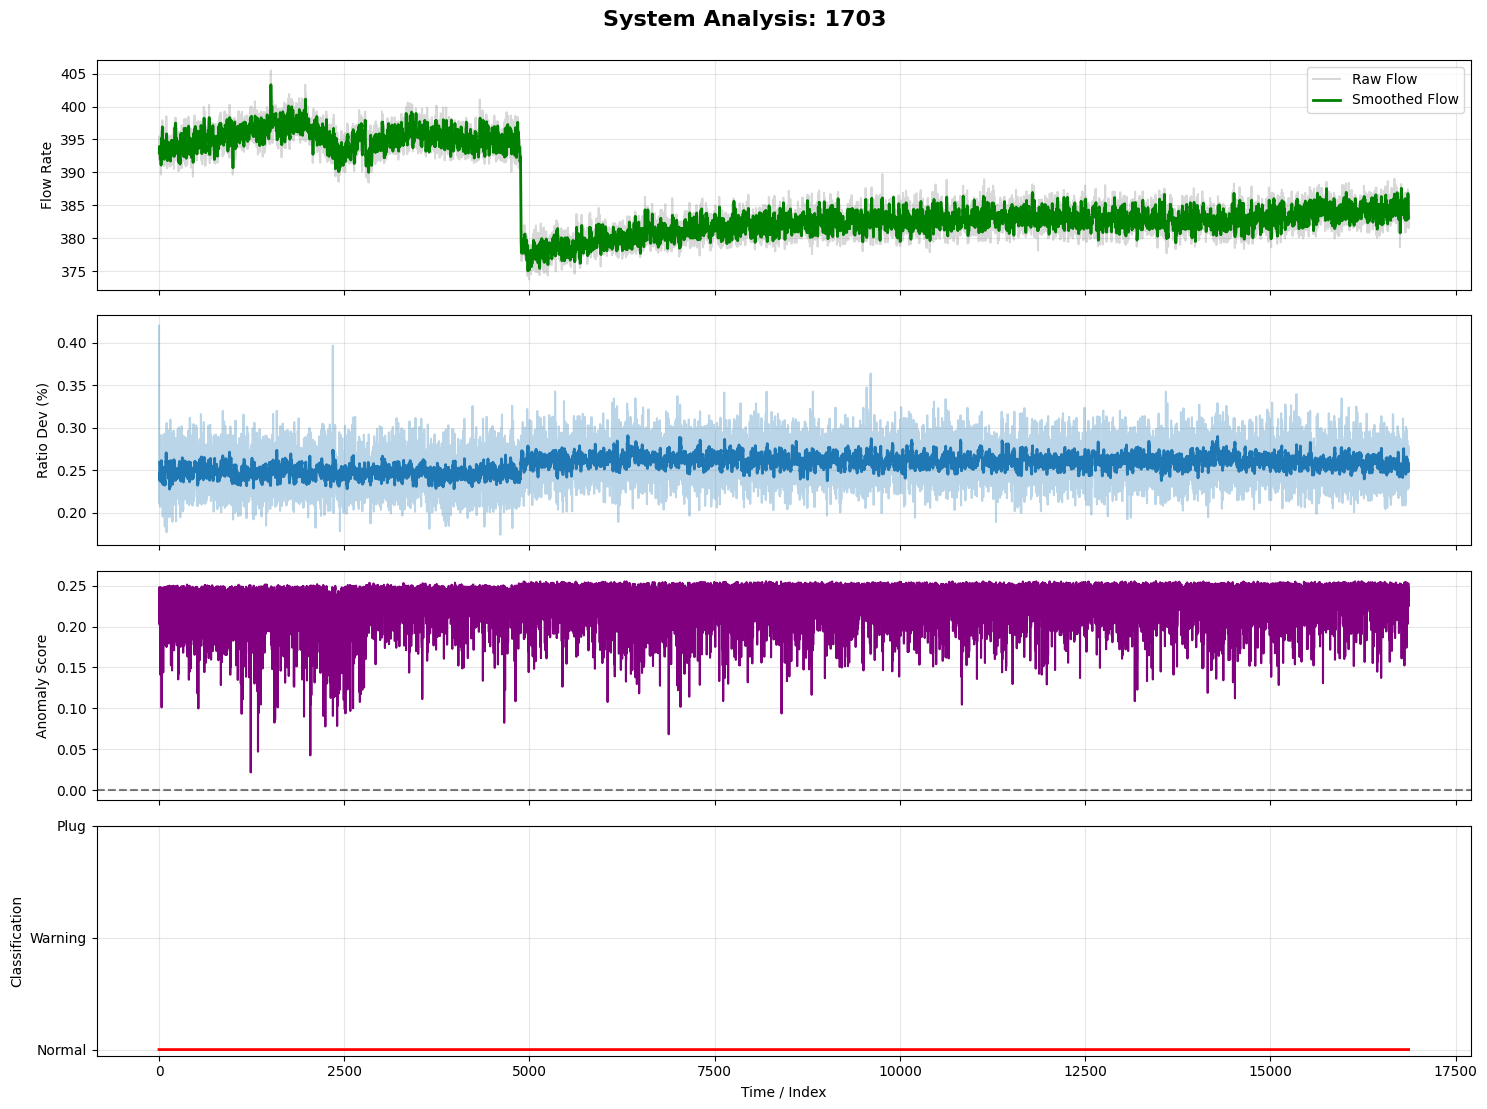

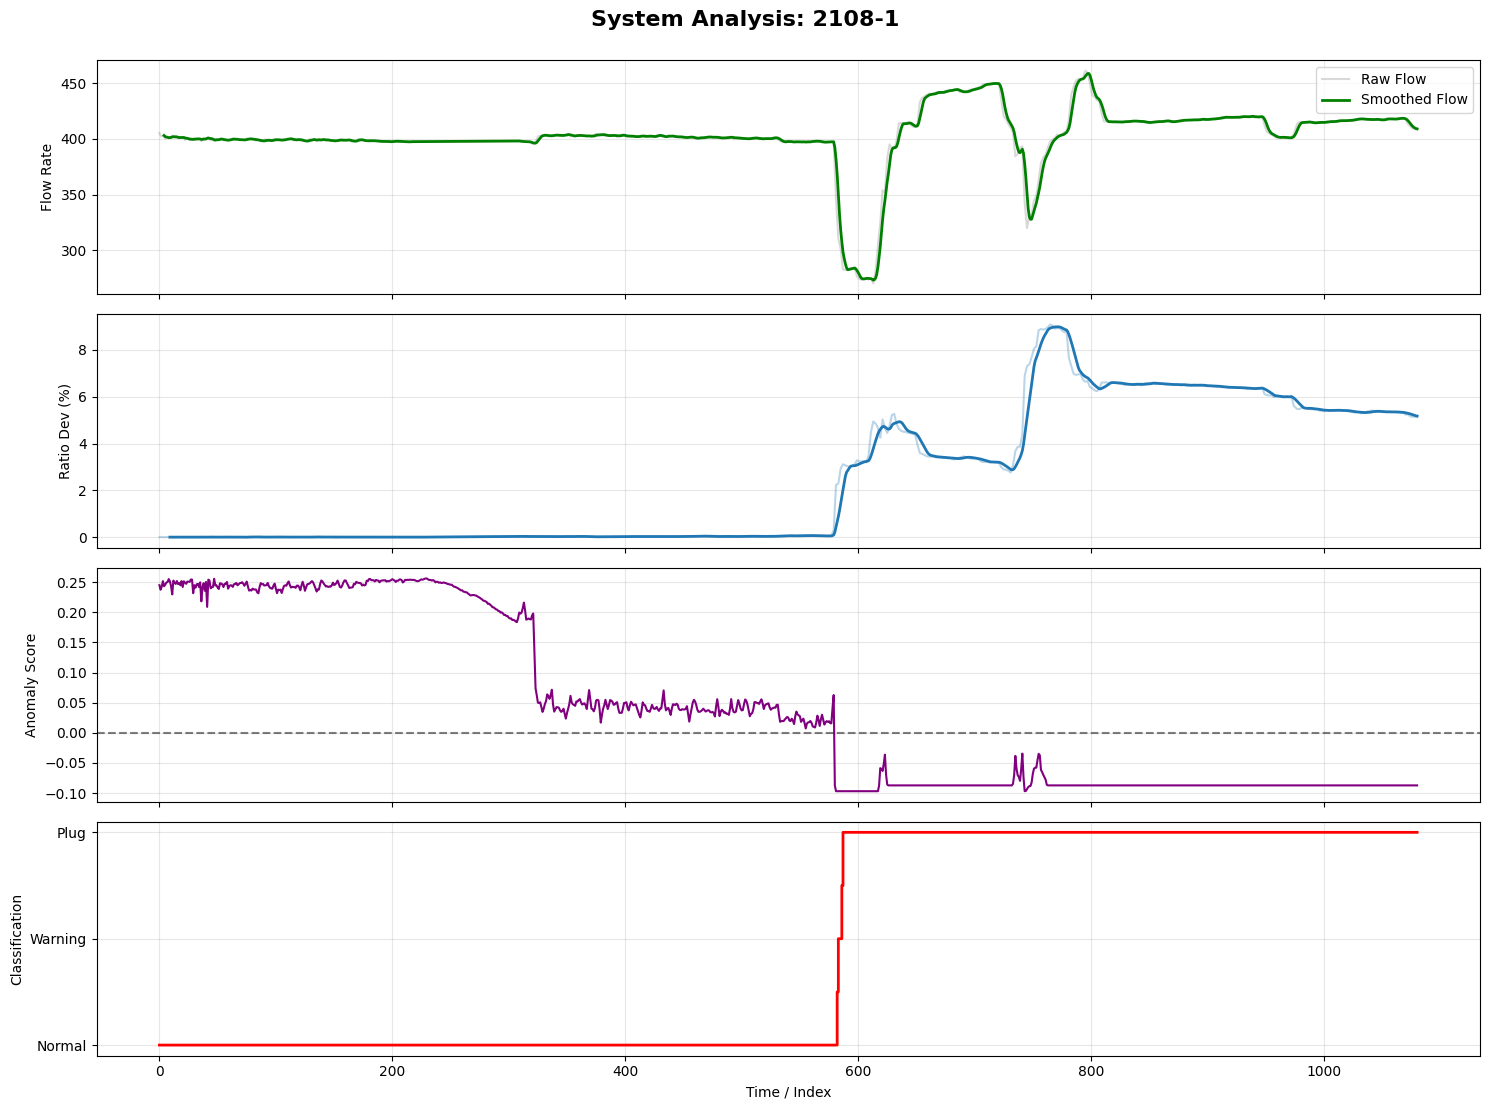

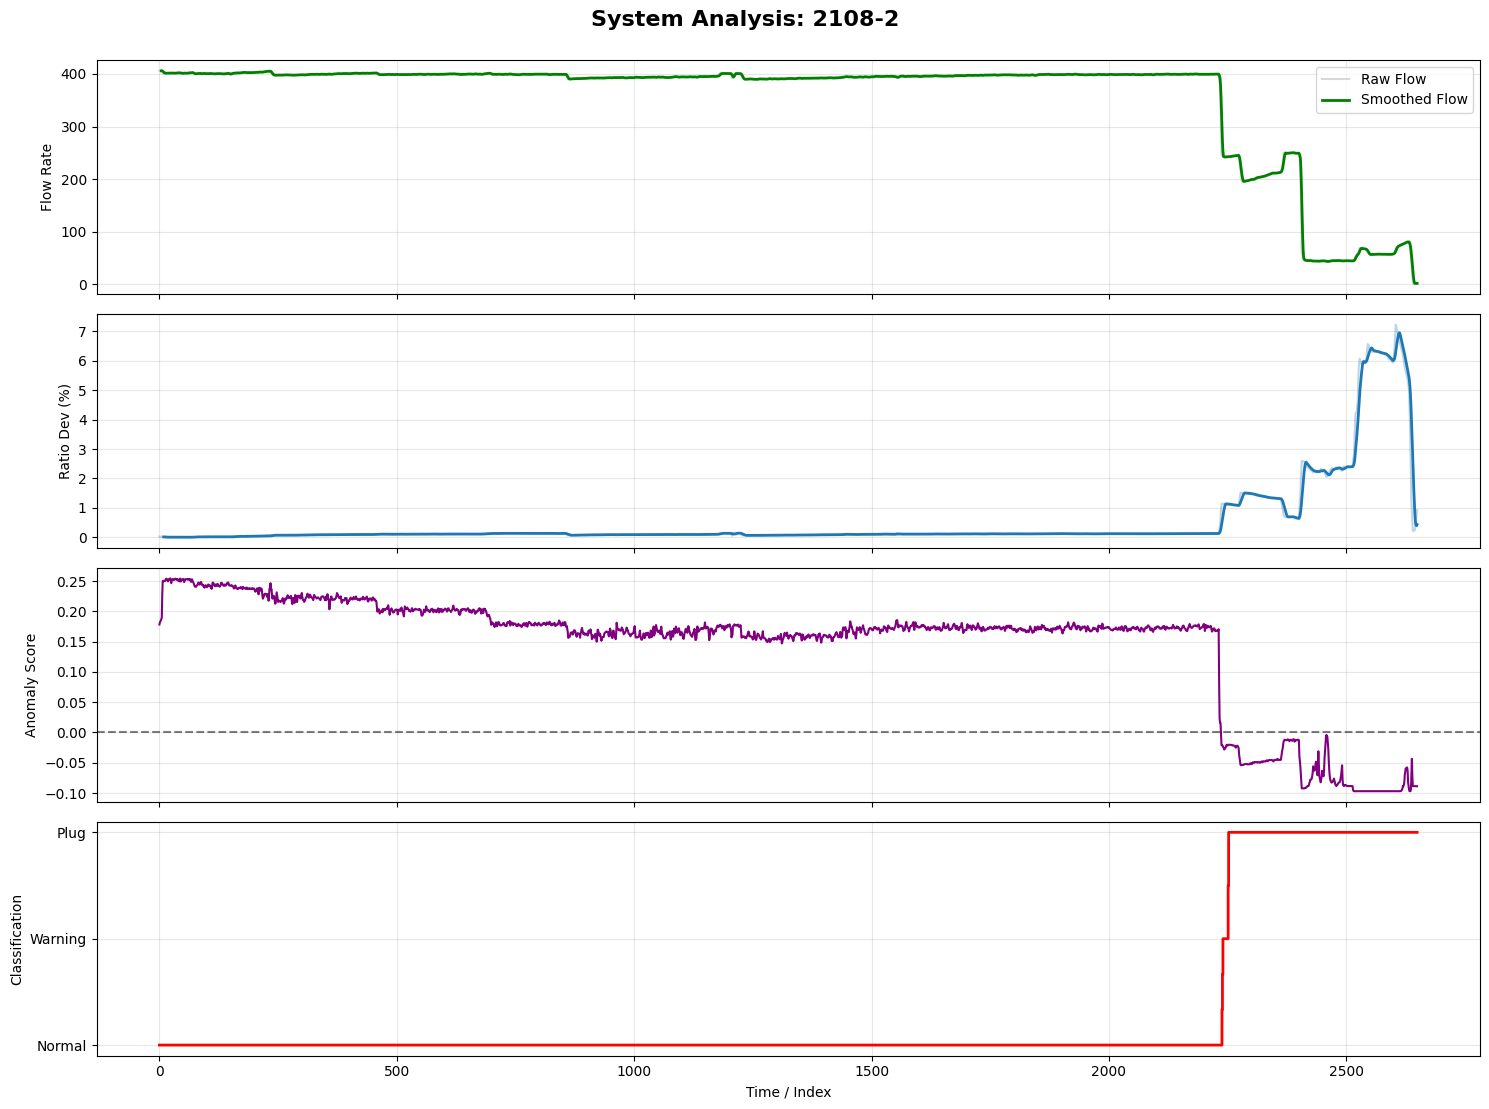

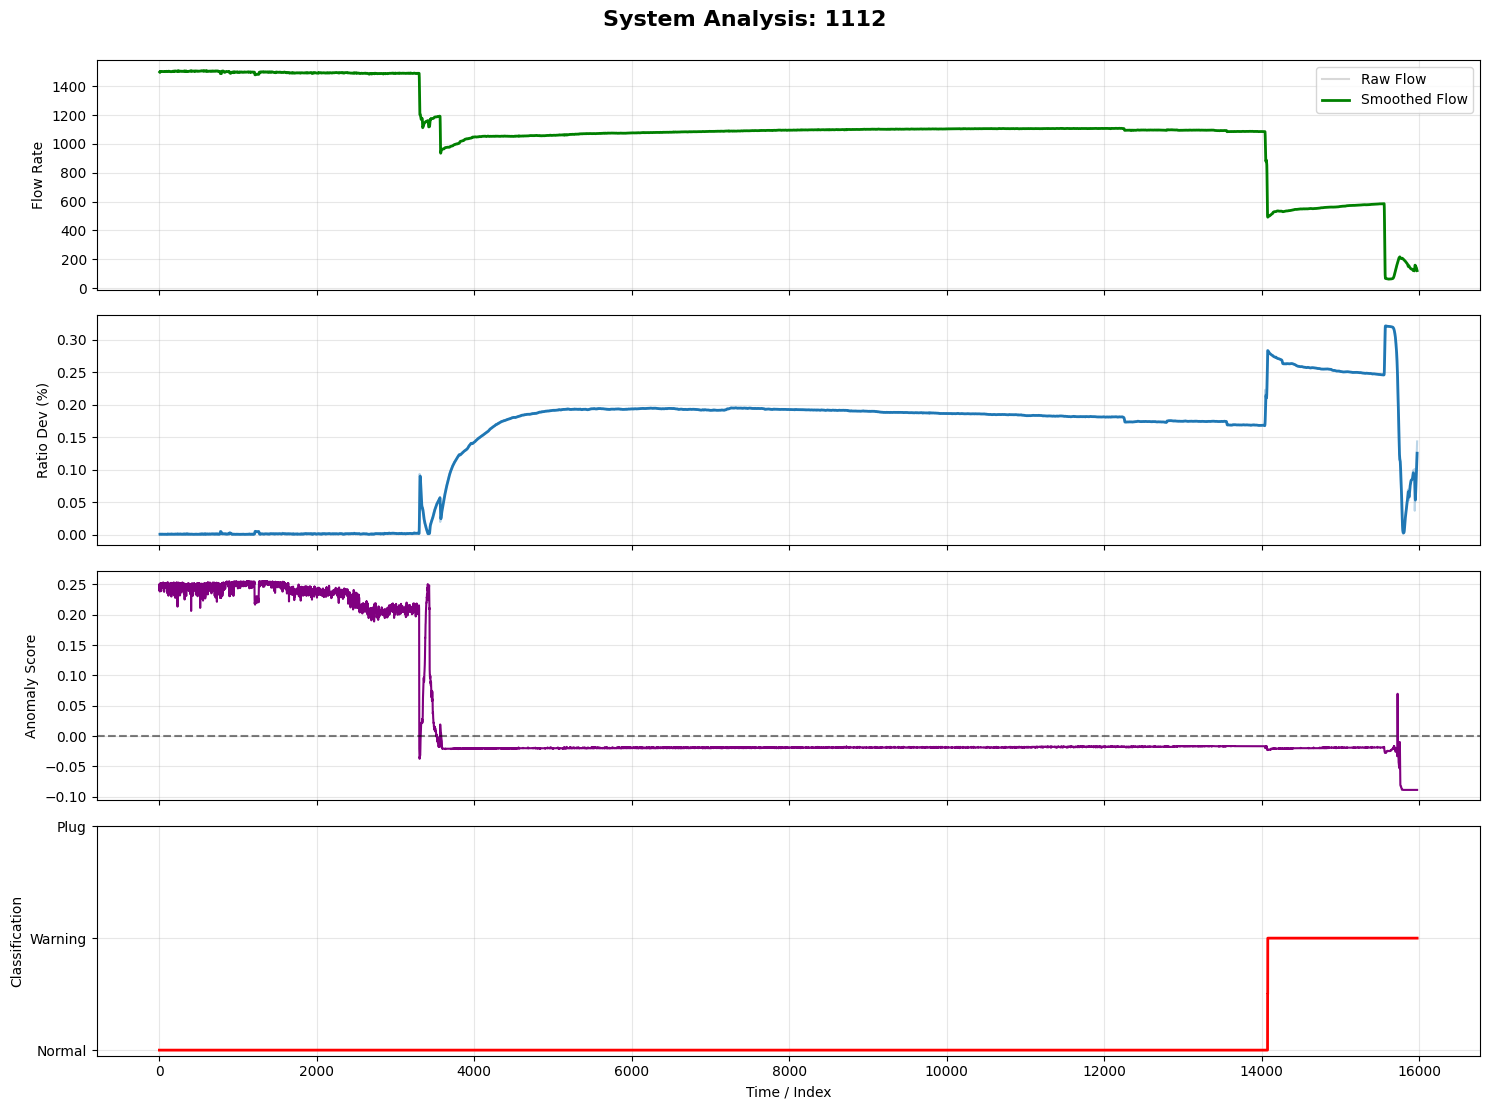

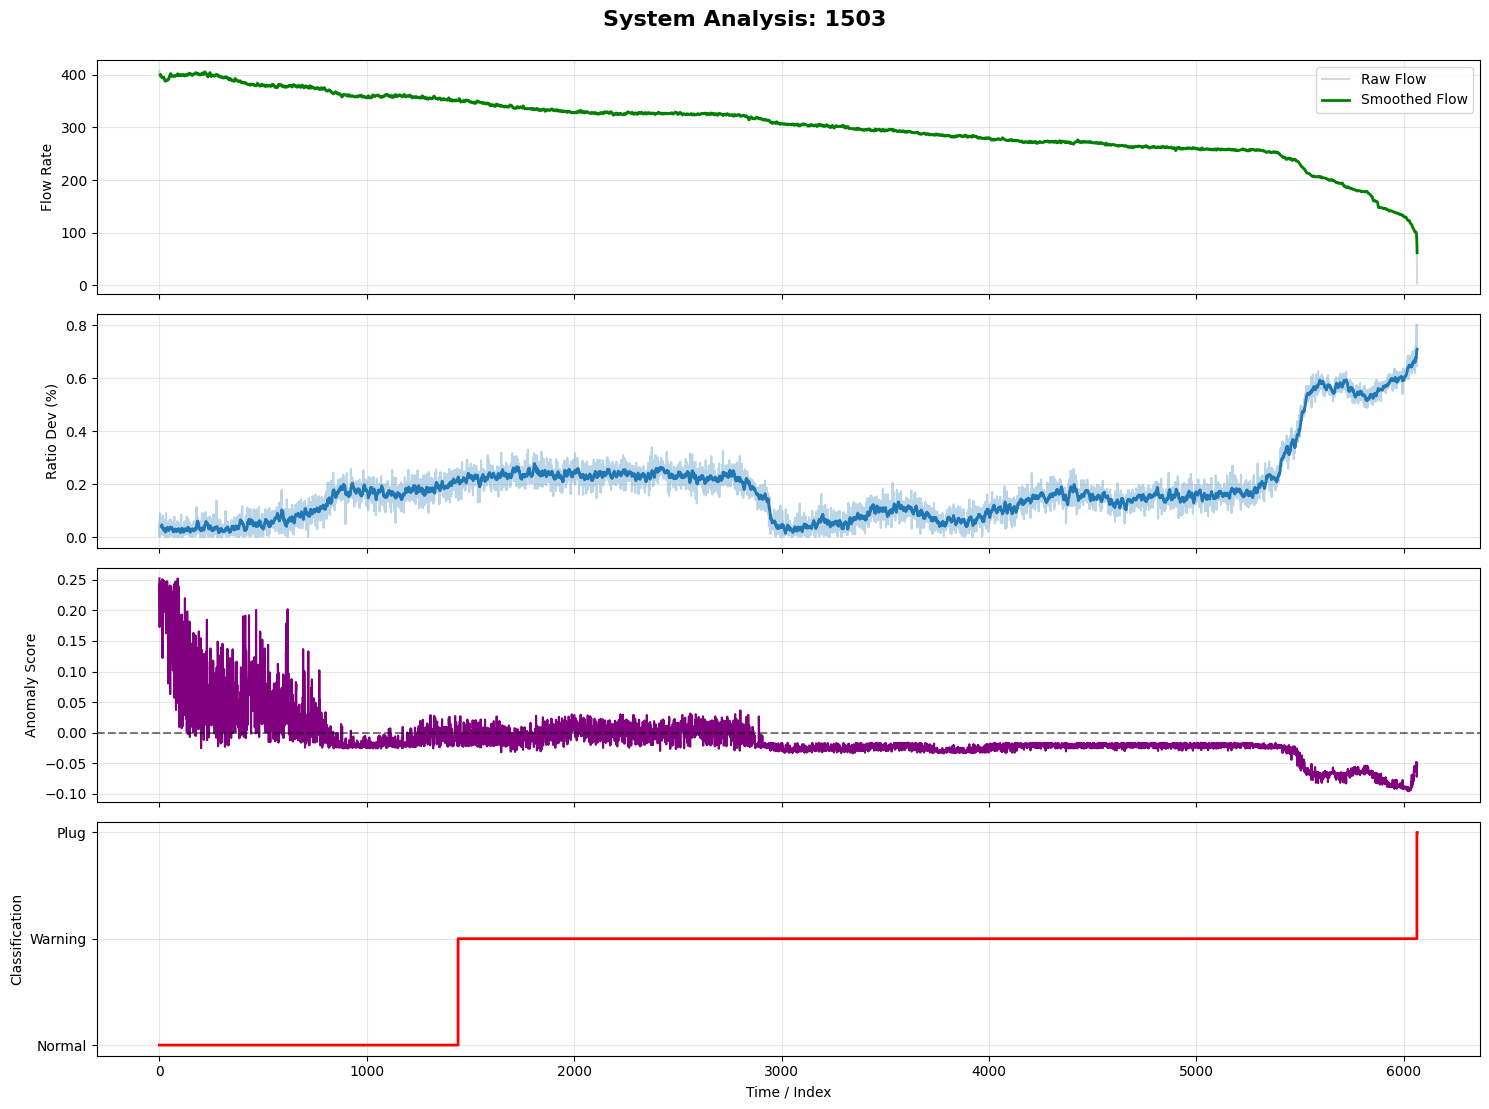

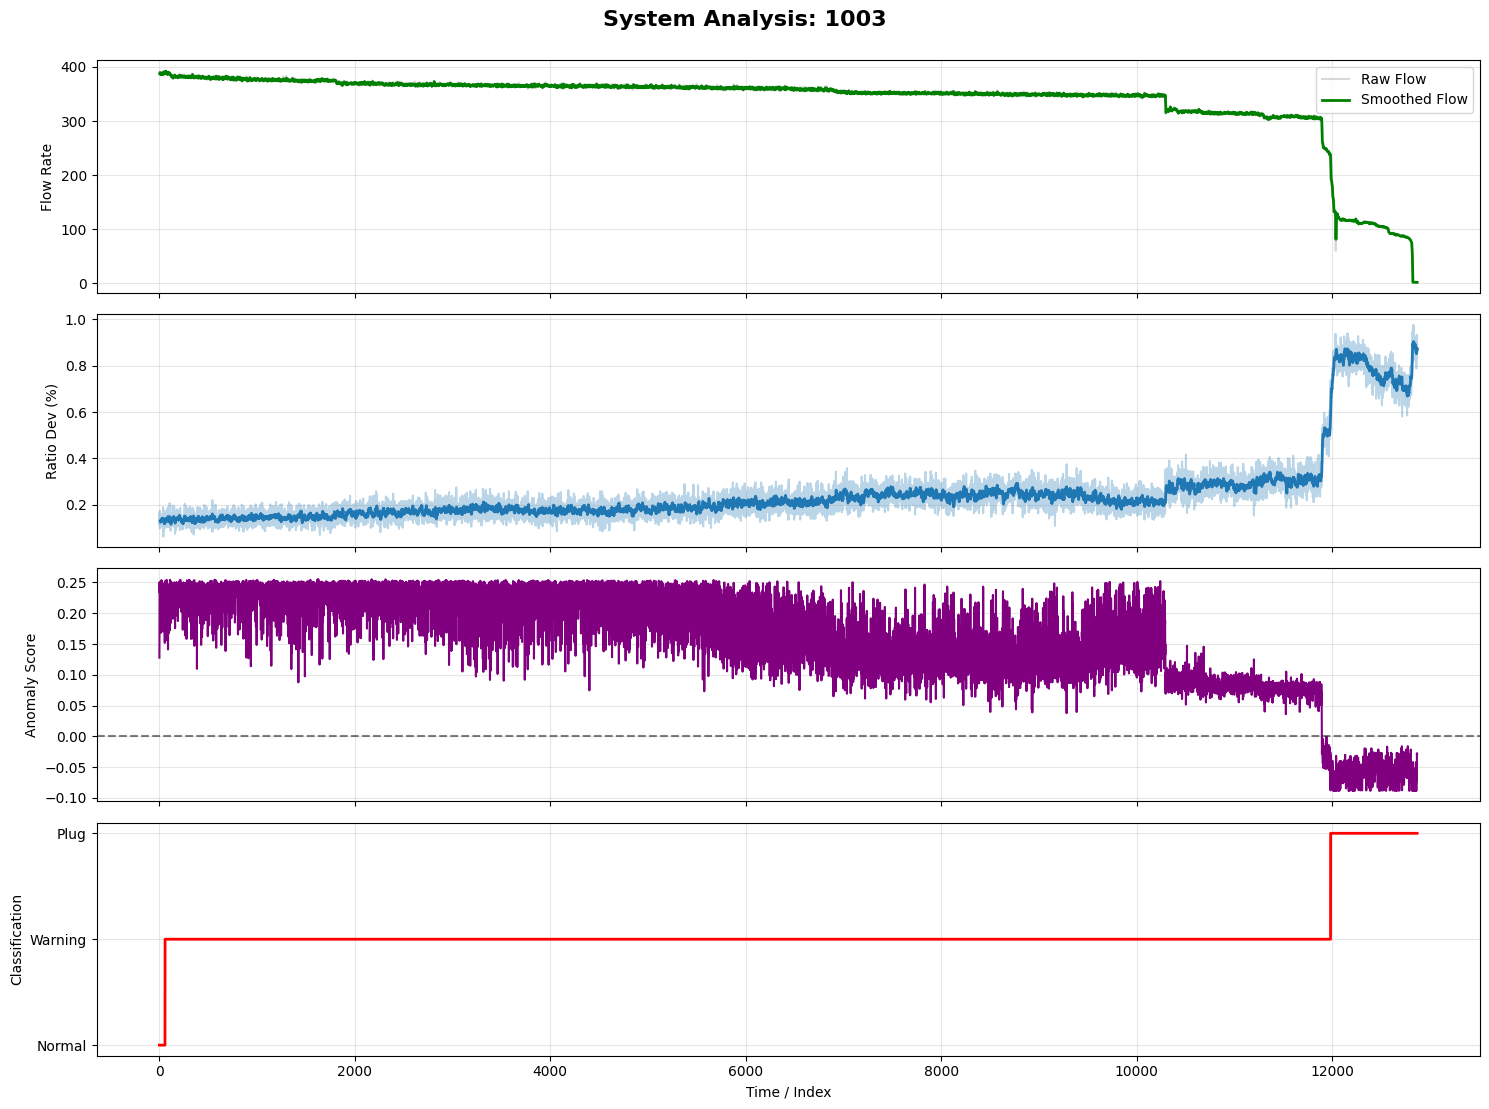

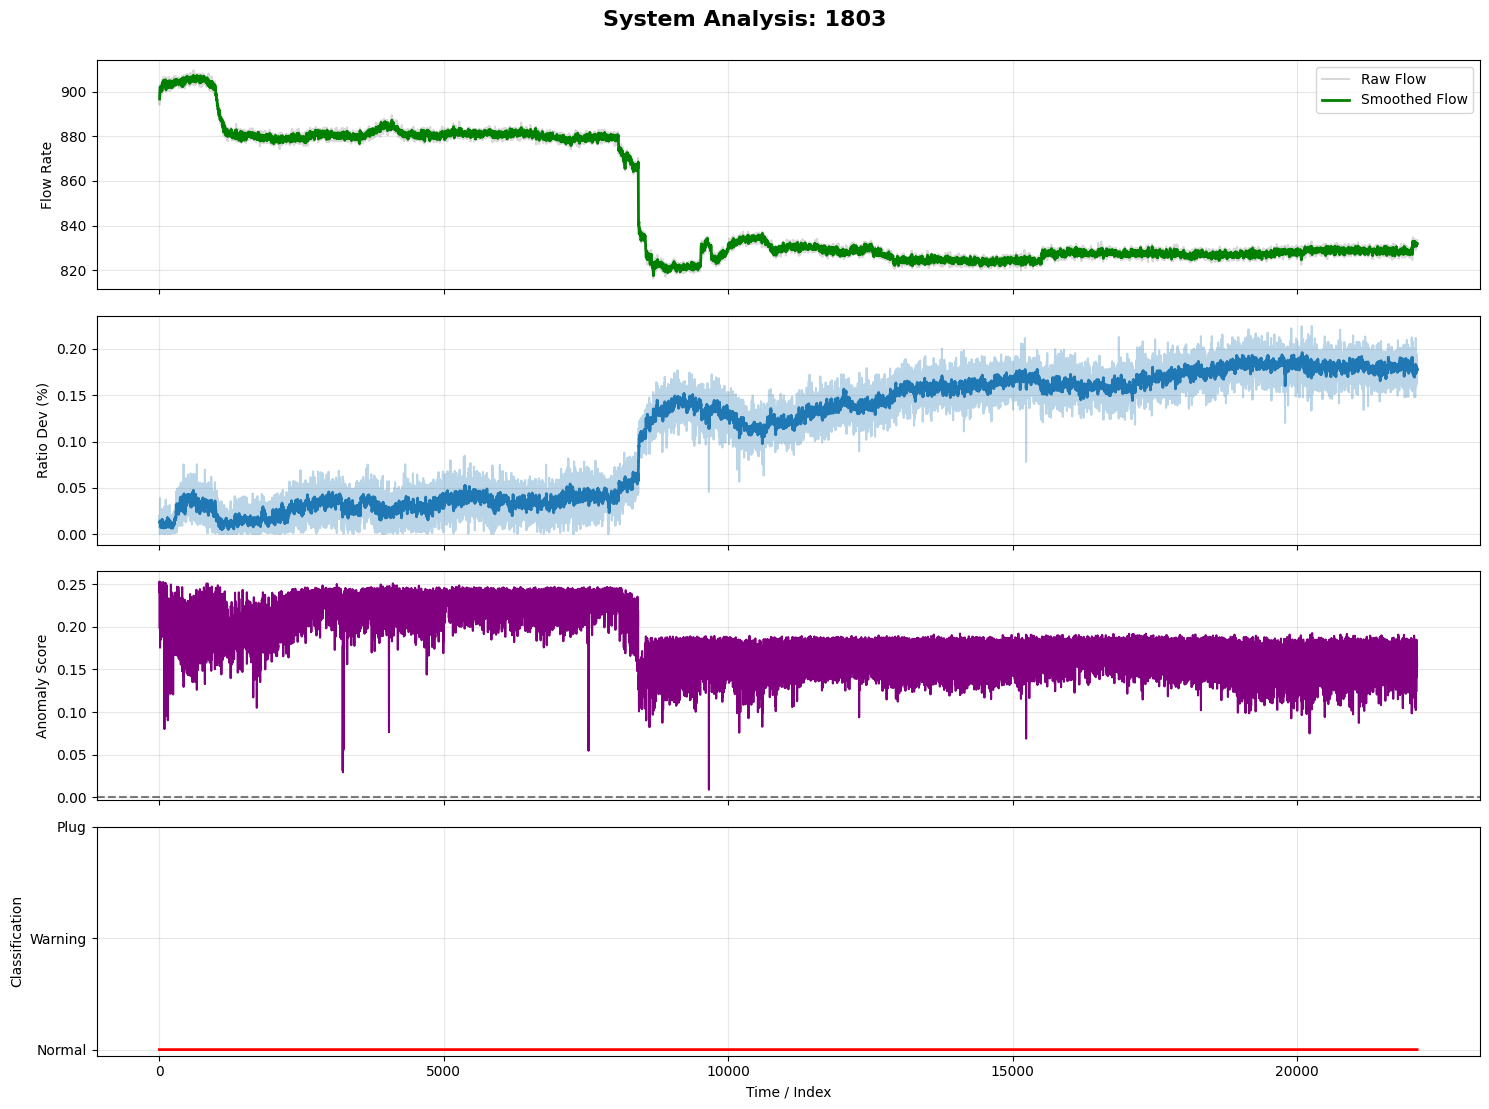

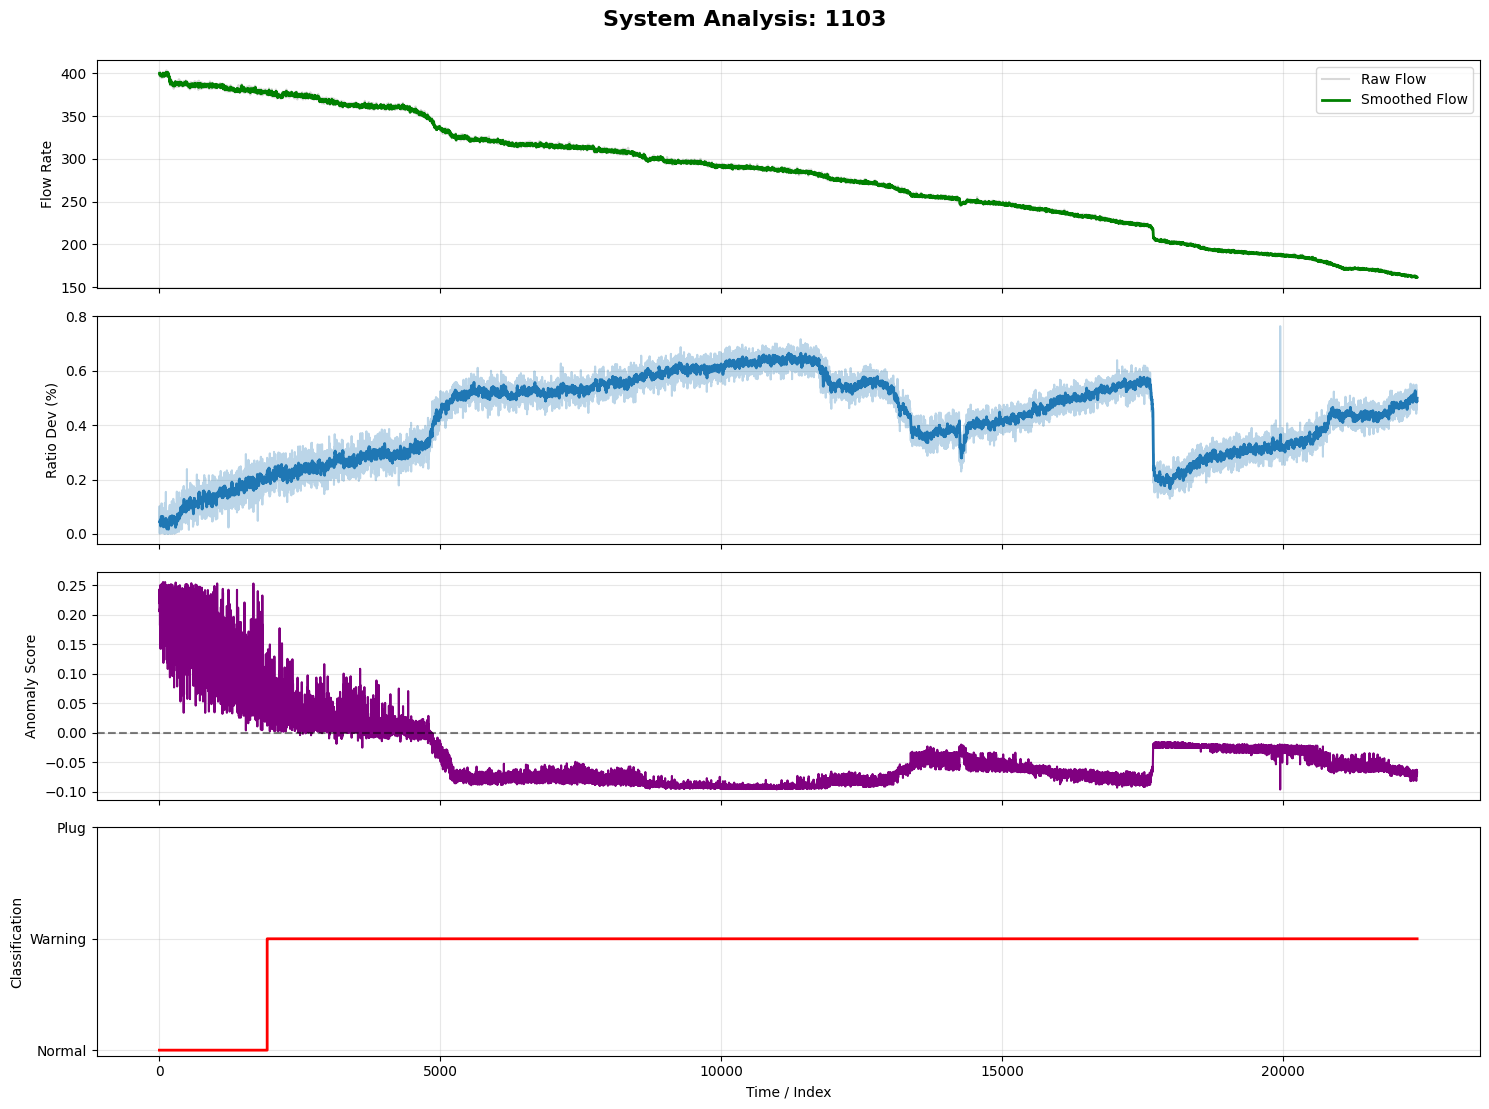

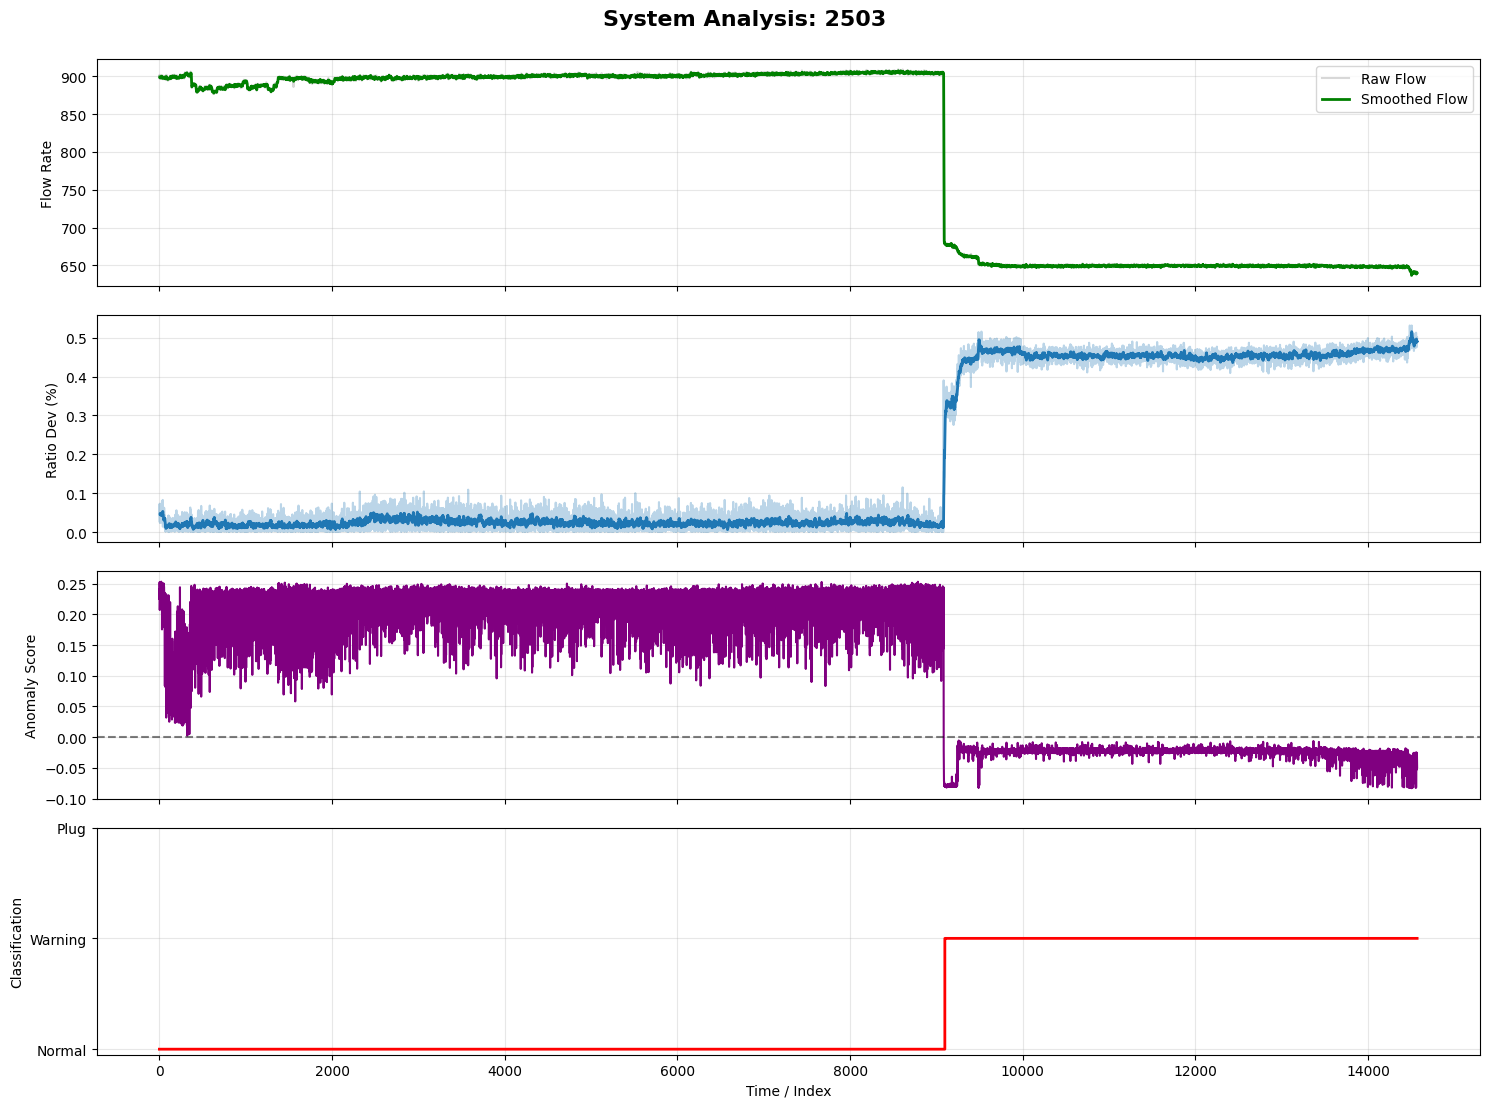

In [24]:
import matplotlib.pyplot as plt
import math

def plot_system_validation(dfs, names, flow_smooth=5, ratio_smooth=10):
    for i, df in enumerate(dfs):
        fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
        fig.suptitle(f"System Analysis: {names[i]}", fontsize=16, fontweight='bold', y=0.95)
        
        # 1. Flow Rate (The Ground Truth)
        # Usually, when a plug happens, the flow rate drops significantly.
        ax0 = axes[0]
        ax0.plot(df.index, df['Flow rate (Mean)'], color='gray', alpha=0.3, label='Raw Flow')
        ax0.plot(df.index, df['Flow rate (Mean)'].rolling(flow_smooth).mean(), color='green', linewidth=2, label='Smoothed Flow')
        ax0.set_ylabel("Flow Rate")
        ax0.legend(loc='upper right')
        ax0.grid(True, alpha=0.3)

        # 2. Relative Ratio Dev 
        ax1 = axes[1]
        ax1.plot(df.index, df['Relative_Ratio_Dev'], color='tab:blue', alpha=0.3)
        ax1.plot(df.index, df['Relative_Ratio_Dev'].rolling(ratio_smooth).mean(), color='tab:blue', linewidth=2, label='Ratio Dev')
        ax1.set_ylabel("Ratio Dev (%)")
        ax1.grid(True, alpha=0.3)

        # 3. Anomaly Score 
        ax2 = axes[2]
        ax2.plot(df.index, df['anomaly_score'], color='purple', linewidth=1.5, label='Anomaly Score')
        ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5) # The 0-line for Isolation Forest/OCSVM
        ax2.set_ylabel("Anomaly Score")
        ax2.grid(True, alpha=0.3)

        # 4. Plug Label (The Target)
        ax3 = axes[3]
        ax3.step(df.index, df['Plug_Label'], where='post', color='red', linewidth=2, label='State (0-2)')
        ax3.set_yticks([0, 1, 2])
        ax3.set_yticklabels(['Normal', 'Warning', 'Plug'])
        ax3.set_ylabel("Classification")
        ax3.set_xlabel("Time / Index")
        ax3.grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Run the validation
plot_system_validation(dfs, df_names)